# Verification & Validation

Core-profile이 존재하는 전체 샷의 모든 타임포인트에서 다음을 비교합니다.

- $P_e^{(vol)} = 2 \langle n_e \rangle_V \langle T_e \rangle_V e$ (`Z_eff` 무시)
- equilibrium으로부터 계산한 $\langle P \rangle_V$

결과를 `workflow/automatic_pipeline_3_data_summary/volume_averaged_parameters.xlsx`에 저장하고,
최종적으로 `2*P_e` vs `P` scatter plot을 그립니다.

In [29]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 13,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

import vaft

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "workflow").exists() else cwd.parent
workflow_dir = repo_root / "workflow" / "automatic_pipeline_3_data_summary"

if str(workflow_dir) not in sys.path:
    sys.path.append(str(workflow_dir))

from gen_volume_averaged_parameter_sheet import generate_volume_averaged_parameter_sheet

output_path = workflow_dir / "volume_averaged_parameters.xlsx"
print(f"repo_root: {repo_root}")
print(f"output_path: {output_path}")

repo_root: /Users/yun/git/vaft
output_path: /Users/yun/git/vaft/workflow/automatic_pipeline_3_data_summary/volume_averaged_parameters.xlsx


In [30]:
# confinement_time_scaling.ipynb와 동일한 방식으로 core_profile 샷 선택
status_df = vaft.database.exist_ts_file()
core_profile_shots = status_df[status_df["Status"] == "core_profile"]["Shot Number"].astype(int).tolist()

print(f"core_profile shot count: {len(core_profile_shots)}")
core_profile_shots[:10]

Available Thomson Scattering Shots:

|   Index |   Shot Number | Last Processed             | Status       |
|---------|---------------|----------------------------|--------------|
|       1 |         22027 | 2023-02-02T23:24:20        | invalid      |
|       2 |         39513 | 2024-08-06T11:18:45.556514 | thomson_only |
|       3 |         39515 | 2024-08-06T11:19:39.748631 | thomson_only |
|       4 |         39906 | 2024-08-06T11:20:05.668157 | core_profile |
|       5 |         39915 | 2024-05-14T16:42:35.439538 | invalid      |
|       6 |         39916 | 2024-07-08T20:11:09.953256 | core_profile |
|       7 |         39917 | 2023-07-05T20:47:14        | core_profile |
|       8 |         40282 | 2024-08-06T11:20:28.826835 | core_profile |
|       9 |         40323 | 2023-07-28T16:04:09        | thomson_only |
|      10 |         40324 | 2023-07-28T16:05:23        | thomson_only |
|      11 |         40325 | 2023-07-28T16:06:39        | core_profile |
|      12 |         40326 |

[39906, 39916, 39917, 40282, 40325, 40326, 40327, 40330, 40331, 41262]

In [31]:
# 모든 core_profile 샷의 가능한 타임포인트에서 volume_averaged 파라미터 추출 후 엑셀 저장
# True: 기존 엑셀만 로드 (재생성·타겟 샷 스캔 스킵). False: 누락/불완전 샷 재생성 시도
SKIP_VOLUME_AVERAGED_REGEN = True

from gen_volume_averaged_parameter_sheet import (
    EXPECTED_COLUMNS,
    REQUIRED_COLUMNS_FOR_REPAIR,
    _get_target_shots,
    _load_existing_or_empty,
)

existing_df = _load_existing_or_empty(str(output_path), EXPECTED_COLUMNS)

if SKIP_VOLUME_AVERAGED_REGEN:
    print(
        "SKIP_VOLUME_AVERAGED_REGEN=True: 기존 엑셀만 사용합니다. "
        "재생성하려면 SKIP_VOLUME_AVERAGED_REGEN=False 로 설정하세요."
    )
    volume_df = existing_df.sort_values(["shot", "time_core_s", "cp_index"]).reset_index(drop=True)
else:
    target_shots, completed_count, missing_count, defective_count = _get_target_shots(
        core_profile_shots,
        existing_df,
        REQUIRED_COLUMNS_FOR_REPAIR,
    )

    print(
        f"candidates={len(core_profile_shots)}, already_complete={completed_count}, "
        f"missing={missing_count}, defective={defective_count}, to_process={len(target_shots)}"
    )

    if len(target_shots) == 0:
        print("All target shots are already generated. Reusing existing Excel without regeneration.")
        volume_df = existing_df.sort_values(["shot", "time_core_s", "cp_index"]).reset_index(drop=True)
    else:
        volume_df = generate_volume_averaged_parameter_sheet(
            shot_numbers=core_profile_shots,
            max_shots=None,
            directory="public",
            output_path=str(output_path),
            show_shot_progress=True,
        )

if volume_df is None:
    raise RuntimeError("No rows extracted. Check data availability and server connection.")

volume_df.head()

SKIP_VOLUME_AVERAGED_REGEN=True: 기존 엑셀만 사용합니다. 재생성하려면 SKIP_VOLUME_AVERAGED_REGEN=False 로 설정하세요.


,shot,cp_index,eq_index,time_core_s,time_equilibrium_s,time_diff_s,n_e_vol_avg_m-3,T_e_vol_avg_eV,P_e_vol_avg_Pa,P_eq_vol_avg_Pa,P_e_over_P_eq
0,39906,0,0,0.321,0.321,0,4410702234324710912,35.789560,50.582989,4.230719,11.956120
1,39906,1,1,0.322,0.322,0,9962758724047579136,75.750538,241.827521,3.635011,66.527323
2,39906,2,2,0.323,0.323,0,7395515039703876608,111.046544,263.156355,3.064171,85.881733
3,39906,3,3,0.324,0.324,0,17440700648845350912,120.079906,671.080558,2.581204,259.987465
4,39916,0,0,0.316,0.316,0,575419614148888320,110.212547,20.321515,10.610451,1.915236


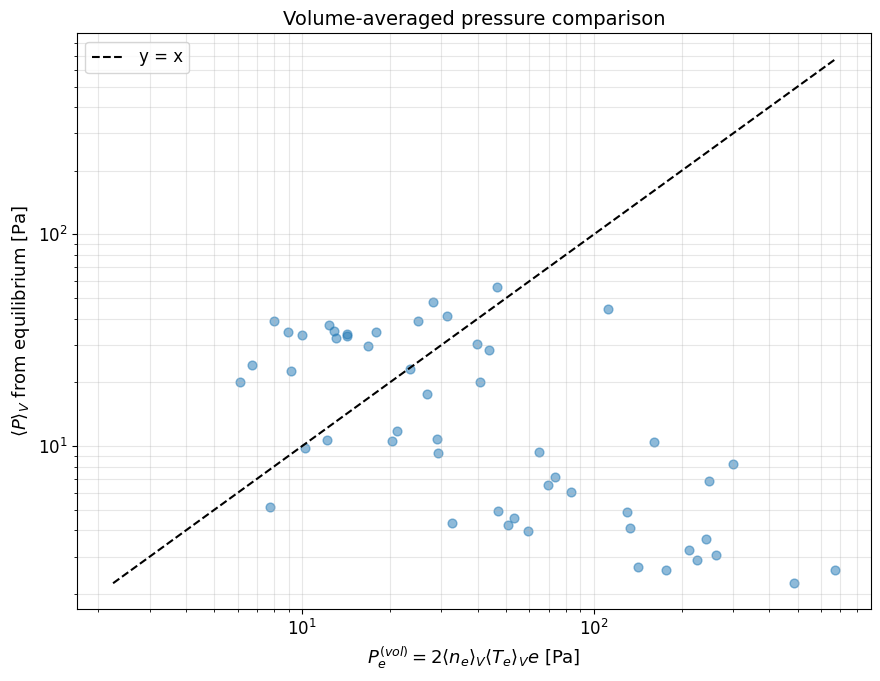

Valid points: 52


,shot,time_core_s,P_e_vol_avg_Pa,P_eq_vol_avg_Pa,P_e_over_P_eq
0,39906,0.321,50.582989,4.230719,11.956120
1,39906,0.322,241.827521,3.635011,66.527323
2,39906,0.323,263.156355,3.064171,85.881733
3,39906,0.324,671.080558,2.581204,259.987465
4,39916,0.316,20.321515,10.610451,1.915236


In [32]:
# 생성된 시트를 다시 로드해서 2*P_e vs P scatter plot
plot_df = pd.read_excel(output_path)
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["P_e_vol_avg_Pa", "P_eq_vol_avg_Pa"])
plot_df = plot_df[(plot_df["P_e_vol_avg_Pa"] > 0) & (plot_df["P_eq_vol_avg_Pa"] > 0)]

plt.figure(figsize=(9, 7))
plt.scatter(plot_df["P_e_vol_avg_Pa"], plot_df["P_eq_vol_avg_Pa"], s=40, alpha=0.5)

x_min = min(plot_df["P_e_vol_avg_Pa"].min(), plot_df["P_eq_vol_avg_Pa"].min())
x_max = max(plot_df["P_e_vol_avg_Pa"].max(), plot_df["P_eq_vol_avg_Pa"].max())
line_x = np.logspace(np.log10(x_min), np.log10(x_max), 200)
plt.plot(line_x, line_x, "k--", linewidth=1.5, label="y = x")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$P_e^{(vol)} = 2\langle n_e\rangle_V\langle T_e\rangle_V e$ [Pa]")
plt.ylabel(r"$\langle P\rangle_V$ from equilibrium [Pa]")
plt.title("Volume-averaged pressure comparison")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Valid points: {len(plot_df)}")
plot_df[["shot", "time_core_s", "P_e_vol_avg_Pa", "P_eq_vol_avg_Pa", "P_e_over_P_eq"]].head()

## Equilibrium Global History V&V

`gen_equilibrium_global_history.py`를 이용해 equilibrium 히스토리를 생성하고,
아래 3가지 비교를 수행합니다.

- `volume_beta_p`(x) 대비 `virial_beta_p_lao`, `virial_beta_p_bongard`(y)
- `volume_li`(x) 대비 `virial_li_lao`, `virial_li_bongard`(y)
- `measured_dia_flux` vs `calculated_dia_flux` (`dia_flux_cmp_measured_Wb` vs `dia_flux_cmp_computed_Wb`)

In [33]:
# True: 기존 엑셀만 로드 (전체 샷 재추출 스킵). False: processed shot 전체 기준 재생성
SKIP_EQUILIBRIUM_GLOBAL_REGEN = True

from gen_equilibrium_global_history import (
    EXPECTED_COLUMNS,
    SORT_COLUMNS,
    _load_existing_or_empty,
    generate_equilibrium_global_history_excel,
)

eq_output_path = workflow_dir / "equilibrium_global_history.xlsx"

if SKIP_EQUILIBRIUM_GLOBAL_REGEN:
    print(
        "SKIP_EQUILIBRIUM_GLOBAL_REGEN=True: 기존 엑셀만 사용합니다. "
        "재생성하려면 SKIP_EQUILIBRIUM_GLOBAL_REGEN=False 로 설정하세요."
    )
    eq_df = _load_existing_or_empty(str(eq_output_path), EXPECTED_COLUMNS)
    if not eq_df.empty:
        eq_df = eq_df.sort_values(SORT_COLUMNS).reset_index(drop=True)
else:
    # 전체 processed shot 기준 equilibrium 히스토리 생성
    # (exist_ts_file()의 Shot Number 전체)
    eq_df = generate_equilibrium_global_history_excel(
        shot_numbers=None,
        max_shots=None,
        directory="public",
        output_path=str(eq_output_path),
    )

if eq_df is None:
    raise RuntimeError("No equilibrium rows extracted. Check data availability and server connection.")

if not SKIP_EQUILIBRIUM_GLOBAL_REGEN:
    print(f"Saved: {eq_output_path}")
eq_df.head()

SKIP_EQUILIBRIUM_GLOBAL_REGEN=True: 기존 엑셀만 사용합니다. 재생성하려면 SKIP_EQUILIBRIUM_GLOBAL_REGEN=False 로 설정하세요.


,shot,eq_index,time_s,ip_A,psi_axis_Wb,psi_boundary_Wb,q_axis,q_95,q_min,beta_pol,...,dia_flux_cmp_measured_Wb,dia_flux_cmp_computed_Wb,dia_flux_cmp_difference_Wb,dia_flux_cmp_relative_error,virial_beta,virial_li,virial_beta_lao,virial_li_lao,virial_beta_bongard,virial_li_bongard
0,39513,0,0.320,49416.86636,0.011527,0.0,3.265835,9.866339,3.265835,0.010329,...,-0.000479,-0.000631,-0.000153,0.318634,-0.220967,-1.389648,-0.220967,-1.389648,-0.524925,0.056726
1,39515,0,0.323,27970.36530,0.004573,0.0,2.646181,5.019180,2.646043,0.001835,...,-0.000206,-0.000151,0.000055,-0.267283,-0.813209,-0.416458,-0.813209,-0.416458,-0.625811,0.219558
2,39906,0,0.321,50906.31309,0.010271,0.0,2.916290,7.149103,2.916290,0.005255,...,-0.000547,-0.000526,0.000020,-0.037118,-0.795646,-0.375099,-0.795646,-0.375099,-0.548475,0.086145
3,39906,1,0.322,47106.14109,0.009020,0.0,2.791700,6.353740,2.791700,0.004030,...,-0.000484,-0.000432,0.000052,-0.108112,-0.803671,-0.367412,-0.803671,-0.367412,-0.563495,0.109864
4,39906,2,0.323,42981.45654,0.007805,0.0,2.679688,5.701868,2.679688,0.003097,...,-0.000406,-0.000345,0.000061,-0.150567,-0.805225,-0.380551,-0.805225,-0.380551,-0.580032,0.136598


Virial plots: excluded 2 row(s) (Lao: virial_beta_lao < -5 or virial_li_lao > 18).


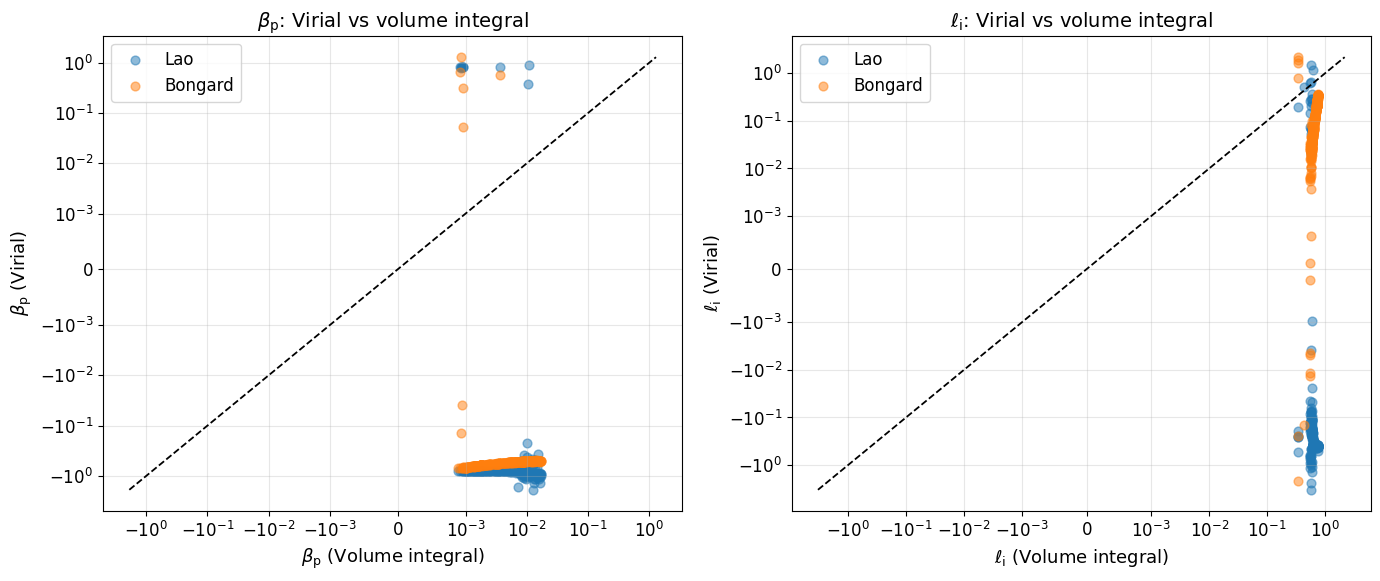

In [37]:
eq_plot_df = pd.read_excel(eq_output_path)
eq_plot_df = eq_plot_df.replace([np.inf, -np.inf], np.nan)

# Virial Lao/Bongard 컬럼 fallback (구버전 시트 호환)
if "virial_beta_lao" not in eq_plot_df.columns:
    eq_plot_df["virial_beta_lao"] = eq_plot_df.get("virial_beta", np.nan)
if "virial_li_lao" not in eq_plot_df.columns:
    eq_plot_df["virial_li_lao"] = eq_plot_df.get("virial_li", np.nan)
if "virial_beta_bongard" not in eq_plot_df.columns:
    eq_plot_df["virial_beta_bongard"] = np.nan
if "virial_li_bongard" not in eq_plot_df.columns:
    eq_plot_df["virial_li_bongard"] = np.nan

# measured/calculated는 compute_diamagnetic_flux_measured_vs_computed 결과 우선 (다음 셀 플롯용)
if "dia_flux_cmp_measured_Wb" not in eq_plot_df.columns:
    eq_plot_df["dia_flux_cmp_measured_Wb"] = eq_plot_df.get("measured_dia_flux_Wb", np.nan)
if "dia_flux_cmp_computed_Wb" not in eq_plot_df.columns:
    eq_plot_df["dia_flux_cmp_computed_Wb"] = eq_plot_df.get("reconstructed_dia_flux_Wb", np.nan)

# Virial vs volume 플롯용: 수치적으로 stiff한 영역 + 극단 outlier 제외
def _num_col(df, col):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(np.nan, index=df.index, dtype=float)

alpha = _num_col(eq_plot_df, "virial_alpha")
b_pa = _num_col(eq_plot_df, "virial_b_pa_T")
v_p = _num_col(eq_plot_df, "virial_volume_m3")
rt = _num_col(eq_plot_df, "virial_rt_m")
r0 = _num_col(eq_plot_df, "major_radius_m")
with np.errstate(divide="ignore", invalid="ignore"):
    rt_over_r0 = rt / r0

# Stiffness criteria (virial closure 분모/스케일 민감영역)
stiff_alpha_lao = (alpha - 1.0).abs() < 0.03        # Lao l_i denominator: (alpha - 1)
stiff_alpha_bongard = (3.0 * alpha - 2.0).abs() < 0.05  # Bongard l_i denominator: (3 alpha - 2)
stiff_small_bpa = b_pa.abs() < 1e-3                 # B_pa^2 scaling 민감영역
stiff_small_volume = v_p <= 1e-4                    # very small plasma volume
rt_ratio_valid = np.isfinite(rt_over_r0) & np.isfinite(r0) & (r0 > 0.0)
stiff_rt_ratio = rt_ratio_valid & ((rt_over_r0 < 0.2) | (rt_over_r0 > 2.5))
virial_stiff = (
    stiff_alpha_lao
    | stiff_alpha_bongard
    | stiff_small_bpa
    | stiff_small_volume
    | stiff_rt_ratio
)

# Legacy hard-cut outlier (가독성 유지용)
_vb = pd.to_numeric(eq_plot_df["virial_beta_lao"], errors="coerce")
_vl = pd.to_numeric(eq_plot_df["virial_li_lao"], errors="coerce")
legacy_outlier = (_vb < -5.0) | (_vl > 18.0)

exclude_mask = virial_stiff | legacy_outlier
eq_vplot = eq_plot_df.loc[~exclude_mask].copy()

print(f"Virial plots: excluded {exclude_mask.sum()} row(s) / {len(eq_plot_df)}.")
print(
    "  - stiff(alpha~1)="
    f"{int(stiff_alpha_lao.sum())}, "
    "stiff(3alpha-2~0)="
    f"{int(stiff_alpha_bongard.sum())}, "
    "small B_pa="
    f"{int(stiff_small_bpa.sum())}, "
    "small volume="
    f"{int(stiff_small_volume.sum())}, "
    "abnormal R_T/R_0="
    f"{int(stiff_rt_ratio.sum())}, "
    "legacy outlier="
    f"{int(legacy_outlier.sum())}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1) volume_beta_p(x) vs virial_beta_p_lao/bongard(y)
ax = axes[0]
sub_lao = eq_vplot[["beta_pol", "virial_beta_lao"]].dropna()
sub_bong = eq_vplot[["beta_pol", "virial_beta_bongard"]].dropna()
if len(sub_lao) > 0:
    ax.scatter(sub_lao["beta_pol"], sub_lao["virial_beta_lao"], s=40, alpha=0.5, label="Lao")
if len(sub_bong) > 0:
    ax.scatter(sub_bong["beta_pol"], sub_bong["virial_beta_bongard"], s=40, alpha=0.5, label="Bongard")
vals = np.concatenate([
    sub_lao.to_numpy(dtype=float).ravel() if len(sub_lao) > 0 else np.array([], dtype=float),
    sub_bong.to_numpy(dtype=float).ravel() if len(sub_bong) > 0 else np.array([], dtype=float),
])
vals = vals[np.isfinite(vals)]
if vals.size > 0 and np.nanmin(vals) != np.nanmax(vals):
    lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.3)
ax.set_xlabel(r"$\beta_{\mathrm{p}}$ (Volume integral)")
ax.set_ylabel(r"$\beta_{\mathrm{p}}$ (Virial)")
ax.set_title(r"$\beta_{\mathrm{p}}$: Virial vs volume integral")
ax.set_xscale("symlog", linthresh=1e-3)
ax.set_yscale("symlog", linthresh=1e-3)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

# 2) volume_li(x) vs virial_li_lao/bongard(y)
ax = axes[1]
sub_lao = eq_vplot[["li_3", "virial_li_lao"]].dropna()
sub_bong = eq_vplot[["li_3", "virial_li_bongard"]].dropna()
if len(sub_lao) > 0:
    ax.scatter(sub_lao["li_3"], sub_lao["virial_li_lao"], s=40, alpha=0.5, label="Lao")
if len(sub_bong) > 0:
    ax.scatter(sub_bong["li_3"], sub_bong["virial_li_bongard"], s=40, alpha=0.5, label="Bongard")
vals = np.concatenate([
    sub_lao.to_numpy(dtype=float).ravel() if len(sub_lao) > 0 else np.array([], dtype=float),
    sub_bong.to_numpy(dtype=float).ravel() if len(sub_bong) > 0 else np.array([], dtype=float),
])
vals = vals[np.isfinite(vals)]
if vals.size > 0 and np.nanmin(vals) != np.nanmax(vals):
    lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.3)
ax.set_xlabel(r"$\ell_{\mathrm{i}}$ (Volume integral)")
ax.set_ylabel(r"$\ell_{\mathrm{i}}$ (Virial)")
ax.set_title(r"$\ell_{\mathrm{i}}$: Virial vs volume integral")
ax.set_xscale("symlog", linthresh=1e-3)
ax.set_yscale("symlog", linthresh=1e-3)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


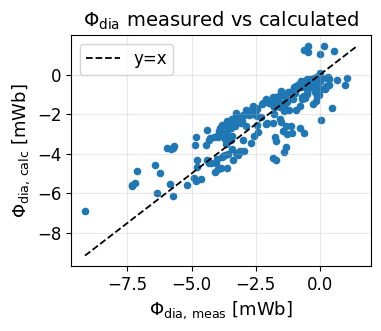

,shot,eq_index,time_s,beta_pol,virial_beta_lao,virial_beta_bongard,li_3,virial_li_lao,virial_li_bongard,dia_flux_cmp_measured_Wb,dia_flux_cmp_computed_Wb
0,39513,0,0.320,0.010329,-0.220967,-0.524925,0.590084,-1.389648,0.056726,-0.000479,-0.000631
1,39515,0,0.323,0.001835,-0.813209,-0.625811,0.704915,-0.416458,0.219558,-0.000206,-0.000151
2,39906,0,0.321,0.005255,-0.795646,-0.548475,0.631490,-0.375099,0.086145,-0.000547,-0.000526
3,39906,1,0.322,0.004030,-0.803671,-0.563495,0.650479,-0.367412,0.109864,-0.000484,-0.000432
4,39906,2,0.323,0.003097,-0.805225,-0.580032,0.668635,-0.380551,0.136598,-0.000406,-0.000345


In [35]:
# measured vs calculated diamagnetic flux (eq_plot_df는 위 셀에서 로드; 시트 단위 Wb → 플롯 축은 mWb)
fig, ax = plt.subplots(figsize=(4, 3.5))
sub = eq_plot_df[["dia_flux_cmp_measured_Wb", "dia_flux_cmp_computed_Wb"]].dropna()
if len(sub) > 0:
    x = sub["dia_flux_cmp_measured_Wb"].to_numpy(dtype=float) * 1e3  # Wb → mWb
    y = sub["dia_flux_cmp_computed_Wb"].to_numpy(dtype=float) * 1e3
    ax.scatter(x, y, s=20)
    lo = float(np.nanmin([np.nanmin(x), np.nanmin(y)]))
    hi = float(np.nanmax([np.nanmax(x), np.nanmax(y)]))
    if np.isfinite(lo) and np.isfinite(hi) and lo != hi:
        ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.3, label='y=x')
ax.set_xlabel(r"$\Phi_{\mathrm{dia,\,meas}}$ [mWb]")
ax.set_ylabel(r"$\Phi_{\mathrm{dia,\,calc}}$ [mWb]")
ax.set_title(r"$\Phi_{\mathrm{dia}}$ measured vs calculated")
ax.set_xscale("symlog", linthresh=1e-4)
ax.set_yscale("symlog", linthresh=1e-4)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

eq_plot_df[[
    "shot",
    "eq_index",
    "time_s",
    "beta_pol",
    "virial_beta_lao",
    "virial_beta_bongard",
    "li_3",
    "virial_li_lao",
    "virial_li_bongard",
    "dia_flux_cmp_measured_Wb",
    "dia_flux_cmp_computed_Wb",
]].dropna(how="all").head()
